In [ ]:
# Importing the necessary libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import kaggle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# Downloading and importing the dataset:
kaggle.api.authenticate()
path = kaggle.api.dataset_download_files("khushikyad001/ai-impact-on-jobs-2030", path=".", unzip=True)
df = pd.read_csv("AI_Impact_on_Jobs_2030.csv")
df.head()

Dataset URL: https://www.kaggle.com/datasets/khushikyad001/ai-impact-on-jobs-2030


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


## The following code block allows for all columns to be displayed in a list. Doing so allows me to see if there are any spaces that shouldn't be there. In this case, none are present and thus, I'm able to access all columns without any issues.

In [4]:
df_columns_list = df.columns.to_list
print(df_columns_list)

<bound method IndexOpsMixin.tolist of Index(['Job_Title', 'Average_Salary', 'Years_Experience', 'Education_Level',
       'AI_Exposure_Index', 'Tech_Growth_Factor',
       'Automation_Probability_2030', 'Risk_Category', 'Skill_1', 'Skill_2',
       'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8',
       'Skill_9', 'Skill_10'],
      dtype='object')>


## To being Exploratory Data Analaysis (EDA), I simply create a color map as a dictionary which I then reference in a 3D scatter plot using Plotly. Here, I prioritized visualizing job title against risk categories which are also color-coded by the same risk catergories. This visualization allows me to see which job titles are at risk of AI automation impacting them.

In [5]:
# Performing Exploratory Data Analysis (EDA):
severity_mapping = {"High": "#FF2800", "Medium": "#FFB300", "Low": "#00FF00"}

fig1 = px.scatter_3d(data_frame=df, x='Job_Title', y='AI_Exposure_Index', z='Risk_Category', color="Risk_Category", color_discrete_map=severity_mapping, template='plotly_dark', title='Job Title AI Impact by Risk Severity & Exposure', width=1000, height= 1000)
fig1

## The next visualization is focused on job titles and their respective risk categories against the tech growth factor, allow me to see the correlation between AI impact and the amount of technological growth for each role.

In [6]:
# Vusualizing the data differently with a bar plot and replacing AI exposure with tech growth potential.
fig2 = px.bar(data_frame=df, x='Job_Title', y='Tech_Growth_Factor', color='Risk_Category', template='plotly_dark', title='Job Title AI Impact by Risk Severity & Industry Growth', width=1000, height= 1000)
fig2

## Next, I wanted to view the data types involved with each of the columns in the dataset. In this case, I'm mostly dealing with just objects (categorical data) and numerical data (float64).

In [7]:
# Now that I have some initial graphs and visualizations to understand the data, I can now proceed with preprocessing and cleansing steps:
#df.isna().sum() # None have been found.
#df.isnull().sum() # None have been found.
# df.dtypes -> #This shows that all data are categorized as either float64 or objects.
df.dtypes

Job_Title                       object
Average_Salary                   int64
Years_Experience                 int64
Education_Level                 object
AI_Exposure_Index              float64
Tech_Growth_Factor             float64
Automation_Probability_2030    float64
Risk_Category                   object
Skill_1                        float64
Skill_2                        float64
Skill_3                        float64
Skill_4                        float64
Skill_5                        float64
Skill_6                        float64
Skill_7                        float64
Skill_8                        float64
Skill_9                        float64
Skill_10                       float64
dtype: object

## Now that I fully understand the data, I've inspected the data and ensured it is clean and usable, I can proceed with preprocessing and transformation. To keep things formal and reduce error, I create two lists containing categorical and numerical features. Then, use them to create a preprocessor with the use of ColumnTransformer and finally create a pipeline that wraps the preprocessor. Finally, I inspect the pipeline and it's steps to ensure it is correct before I proceed.

In [8]:
# Now that cleansing is complete, I can now begin preprocessing steps.:
# Visualizing the risk_category may be better suited as the target variable and thus, a classification model would suffice for this problem.

# This features list will be leveraged for a GridSearchCV implementation later for automated hyperparameter tuning.
# features = ['Job_Title',
#  'Average_Salary',
#  'Years_Experience',
#  'Education_Level',
#  'AI_Exposure_Index',
#  'Tech_Growth_Factor',
#  'Automation_Probability_2030',
#  'Skill_1',
#  'Skill_2',
#  'Skill_3',
#  'Skill_4',
#  'Skill_5',
#  'Skill_6',
#  'Skill_7',
#  'Skill_8',
#  'Skill_9',
#  'Skill_10']

# Preprocessing starts here:
categorical_features = ['Job_Title', 'Education_Level']
numerical_features = [
    'Average_Salary',
    'Years_Experience',
    'AI_Exposure_Index',
    'Tech_Growth_Factor',
    'Automation_Probability_2030',
    'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5',
    'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10'
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_features),
        ("num", StandardScaler(), numerical_features),
    ], remainder="drop")

custom_pipe = Pipeline([
    ('preprocessor', preprocessor)
])
custom_pipe

,steps,"[('preprocessor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Now, I will defined my X and y variables for the features and target class respectively.

In [9]:
# Defining the features and the target class:
X = df.drop('Risk_Category', axis=1)
y = df['Risk_Category']

## With that done, I can proceed to create the training and testing splits from the X and y data, label the target class and apply the pipeline to the training data to preprocess it.

In [10]:
# Applying the pipeline to the dataset and creating the train/test data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

labeler = LabelEncoder()
y_train = labeler.fit_transform(y_train)
y_test  = labeler.transform(y_test)

custom_pipe.fit(X_train)
X_train = custom_pipe.transform(X_train)
X_test  = custom_pipe.transform(X_test)

## Now that the data has been preprocessed/transformed, I can begin to create my GridSearchCV() to automate the hyperparameter tuning process and streamline the optimization of the classifier I will be using. In this case, given this is a classification problem where the goal is to predict the risk category for a role, I will leverage a simple Logistic Regression model with Scikit-Learn. First, I create a dictionary selecting the parameters for the selected classifier which is passed to the GSCV instance, train the model and use it for predictions, and finally I print out the results and visualize the accuracy with a heatmap as well.

In [11]:
# Now that preprocessing is done, I can move on to instantiating a classifier and begin to create the Machine Learning (ML) model.:
lr_gscv_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 50, 100],           
    'class_weight': [None, 'balanced']                
}

lr_GSCV = GridSearchCV(estimator=LogisticRegression(max_iter=1000, n_jobs=None, random_state=42), param_grid=lr_gscv_params, cv=5, verbose=1, scoring='f1_macro', n_jobs=1, return_train_score=True)
lr_GSCV.fit(X_train, y_train)

lr_best_estimator = lr_GSCV.best_estimator_
lr_best_params = lr_GSCV.best_params_
lr_best_results = lr_GSCV.best_score_
lr_predict = lr_best_estimator.predict(X_test)
lr_conf_mat = confusion_matrix(y_test, lr_predict)
lr_class_report = classification_report(y_test, lr_predict)

print("\nThe results are as follows: ",
f"\n{lr_best_estimator}",
f"\n{lr_best_params}",
f"\n{lr_best_results}",
f"\n{lr_class_report}")


# Plotting a heatmap:
fig = px.imshow(lr_conf_mat, text_auto=True, template='plotly_dark', height=650, width=650, color_continuous_scale='ylorBr')
fig.update_layout(title_text="Logistic Regression Confusion Matrix Heatmap", font_size=18)
fig.show()

Fitting 5 folds for each of 14 candidates, totalling 70 fits

The results are as follows:  
LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   random_state=42) 
{'C': 10, 'class_weight': 'balanced'} 
0.9928684865377031 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       148
           1       1.00      1.00      1.00       148
           2       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



In [12]:
lr_f1 = f1_score(y_test, lr_predict, average='weighted')
print(lr_f1)

0.9933557027225902


## With the above results, I can see the the overall performance is extremely good. The F1 score is passed 99% and the TPR, TNR, FPR, FNR is very accurate. I separately decided to leverage the F1-score and stored this in a separate variable so that it can be used to compare agains other models at the end.

## I will now continue to test other models and show/visualize the predictions in different ways. The next model I will leverage is a K-Nearest Neighbor classifier. This is to see how well this particular algorithm performs when determining the risk category of new data based on it's proximity to nearby 'neighbors' stemming from likelihood and similarity. For this, I will reuse the previously defined testing and training data with GridSearchCV(), print the results and redo the heatmap as well for consistency.

In [13]:
# I will now create a KNN model to test out another algorithm against the same dataset. Since preprocessing is done, I just need to defined the parameters for a new GridSearchCV use.
knn_gscv_params = {
    'n_neighbors': list(range(3, 21, 2)),    
    'weights': ['uniform', 'distance'],       
    'p': [1, 2],
    'algorithm': ['auto'],                        
}

knn_GSCV = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=knn_gscv_params, cv=5, verbose=1, scoring='f1_macro', return_train_score=True)
knn_GSCV.fit(X_train, y_train)

knn_best_estimator = knn_GSCV.best_estimator_
knn_best_params = knn_GSCV.best_params_
knn_best_results = knn_GSCV.best_score_
knn_predict = knn_best_estimator.predict(X_test)
knn_conf_mat = confusion_matrix(y_test, knn_predict)
knn_class_report = classification_report(y_test, knn_predict)

print("\nThe results are as follows: ",
f"\n{knn_best_estimator}",
f"\n{knn_best_params}",
f"\n{knn_best_results}",
f"\n{knn_class_report}")

# Plotting the heatmap:
fig = px.imshow(knn_conf_mat, title="KNN Confusion Matrix Heatmap", text_auto=True, template='plotly_dark', height=650, width=650, color_continuous_scale='ylorBr')
fig.show()


Fitting 5 folds for each of 36 candidates, totalling 180 fits

The results are as follows:  
KNeighborsClassifier(n_neighbors=19, p=1) 
{'algorithm': 'auto', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'} 
0.9457633927869239 
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       148
           1       0.99      0.93      0.96       148
           2       0.95      0.99      0.97       304

    accuracy                           0.97       600
   macro avg       0.98      0.96      0.97       600
weighted avg       0.97      0.97      0.97       600



In [14]:
knn_f1 = f1_score(y_test, knn_predict, average='weighted')
print(knn_f1)

0.9666254782177123


## Similarly, I get fantastic performance with the KNN model as well. However, it is slightly less accurate when compared to the LogisticRegression() classifier. As with the previous model, I've stored the F1 score in a new variable specific to this model for comparisons later on.

## Now, I will create a neural network and see how well a more complex form of Machine Learning (ML) can perform against this task. I will leverage the PyTorch framework to create a simpler neural network being a Multi-Layered Perceptron with just 2 fully connected layers. To begin, I will first setup device-agnostic code, introduce randomization and create tensors from the training and testing sets previously obtained. I will then create the dataset and assign it to a data loader.

In [15]:
# As a result of the above KNN, I can see it identified '19' to be the best number of neighbors to determine the unknown data points. This seems to be a great example that can also be used for this type of dataset. However, I will now pivot to creating a more complex machine learning system with PyTorch to see how a neural network can perform. While this may be considered overkill, 
# it is a great way to still understand the performance difference between traditional machine learning and deep learning.
    # Creating device-agnostic code:
device='cuda' if torch.cpu.is_available() else 'cpu'
torch.manual_seed(42)
    # Creating tensors:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # Printing the datatype and shape of the transformed data:
print(f"The datatypes for each split is as follows: \n{X_train_tensor.dtype, X_test_tensor.dtype, y_train_tensor.dtype, y_test_tensor.dtype}\nThe shapes are as follows: \n{X_train_tensor.shape, X_test_tensor.shape, y_train_tensor.shape, y_test_tensor.shape} ")
    # Creating the dataset:
dataset = TensorDataset(X_train_tensor, y_train_tensor)
loader = DataLoader(dataset=dataset, batch_size=32, shuffle=False)

The datatypes for each split is as follows: 
(torch.float32, torch.float32, torch.int64, torch.int64)
The shapes are as follows: 
(torch.Size([2400, 39]), torch.Size([600, 39]), torch.Size([2400]), torch.Size([600])) 


## Fantastic, The above print statement shows the datatype is applied correctly and the sizes match up as well. Now, I can create the MLP neural network (model) and instantiate it.

In [16]:
# With the data now being converted to tensors and verifying this along with the correct shapes, I can now proceed with the creation of the model. In this case, given this is a classification problem, I will leverage a simple Multi-Layered Perceptron (MLP) model.
class MLP(nn.Module):
   def __init__(self, input_size, hidden_size, output_size):
      super(MLP, self).__init__()
      self.fcl1 = nn.Linear(input_size, hidden_size)
      self.fcl2 = nn.Linear(hidden_size, hidden_size)
      self.fcl3 = nn.Linear(hidden_size, output_size)

      # Defining the forward pass:
   def forward(self, x):
      x = F.relu(self.fcl1(x))
      x = self.fcl2(x)
      x = self.fcl3(x)
      self.dropout = nn.Dropout(0.3)
      x = self.dropout(x)
      return x
      
input_size = X_test_tensor.shape[1]
hidden_size = 10
output_size = len(torch.unique(y_train_tensor))

mlp_model = MLP(input_size, hidden_size, output_size)


## Now that the model has been created, I now need to proceed to defined a training loop. I then ensure train and test lists are set so that the results are stored and can be visualized. The final part of this code block simply generates a line graph that shows how the error rate or loss reduces after each epoch.

Epoch 1, Training loss: 1.0370
Epoch 2, Training loss: 0.9148
Epoch 3, Training loss: 0.6401
Epoch 4, Training loss: 0.3652
Epoch 5, Training loss: 0.2553
Epoch 6, Training loss: 0.1886
Epoch 7, Training loss: 0.1751
Epoch 8, Training loss: 0.1691
Epoch 9, Training loss: 0.1576
Epoch 10, Training loss: 0.1511
Epoch 11, Training loss: 0.1466
Epoch 12, Training loss: 0.1583
Epoch 13, Training loss: 0.1517
Epoch 14, Training loss: 0.1570
Epoch 15, Training loss: 0.1443
Epoch 16, Training loss: 0.1473
Epoch 17, Training loss: 0.1307
Epoch 18, Training loss: 0.1394
Epoch 19, Training loss: 0.1539
Epoch 20, Training loss: 0.1350
Epoch 21, Training loss: 0.1372
Epoch 22, Training loss: 0.1398
Epoch 23, Training loss: 0.1329
Epoch 24, Training loss: 0.1363
Epoch 25, Training loss: 0.1280
Epoch 26, Training loss: 0.1281
Epoch 27, Training loss: 0.1372
Epoch 28, Training loss: 0.1417
Epoch 29, Training loss: 0.1289
Epoch 30, Training loss: 0.1345
Epoch 31, Training loss: 0.1288
Epoch 32, Trainin

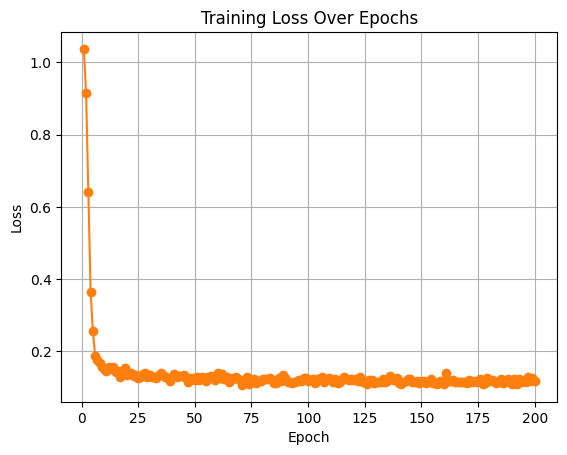

In [17]:
# Now that the model is created and instantiated, I can proceed with going through the training loop for the model:
    # Defining the loss, epochs, training and testing lists and optimizers:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

epochs = 200
train_loss = []
test_loss = []

    # Defining the training loop:
def training_loop():
    for epoch in range(epochs):
        mlp_model.train()
        running_loss = 0.0

        for batch_x, batch_y in loader:
                        # Forward Pass:
            y_pred = mlp_model(batch_x)

            # Calculate the loss:
            loss = criterion(y_pred, batch_y)

            # Optimizer zero grad:
            optimizer.zero_grad()

            # Perform Back Propagation:
            loss.backward()

            # Optimizer Step:
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(loader)
        train_loss.append(avg_loss)
        test_loss.append(loss.item())
        print(f"Epoch {epoch+1}, Training loss: {avg_loss:.4f}")

training_loop()

    # Plotting the epochs to visualize the loss:
plt.plot(range(1, epochs + 1), train_loss, marker='o', color='tab:orange')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


## After reviewing the above results, I can see that the model was able to learn very well as it dramatically reduced it's error rate or loss specifically, after around the first 15 epochs and then plateaus from there. Now that the model is trained, I can use it agains the test data. Finally, the results will be plotted in a new line chart to show the difference between the trained and the testing results.

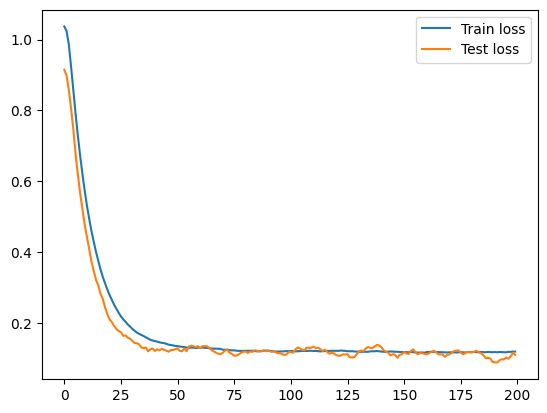

In [18]:
# Now, I will test the model against the testing loss to see how it stacks up against the training loss:
mlp_model.eval()
total_test_loss = 0.0
all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in loader:  # ensure shuffle=False
        outputs = mlp_model(batch_X)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds)
        all_true.append(batch_y)

def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

plt.plot(range(len(train_loss)), smooth_curve(train_loss), label='Train loss')
plt.plot(range(len(test_loss)), smooth_curve(test_loss), label='Test loss')
plt.legend()

In [20]:
# Concatenate all predictions and true labels
all_preds_tensor = torch.cat(all_preds)
all_true_tensor = torch.cat(all_true)

# Convert to NumPy arrays (use .cpu() if using GPU)
y_pred_np = all_preds_tensor.cpu().numpy()
y_true_np = all_true_tensor.cpu().numpy()

# Compute F1 score
mlp_f1_score = f1_score(y_true_np, y_pred_np, average='macro')

print(mlp_f1_score)

0.9046194795895537


## With the above results, I can see that the test loop (orange) remains pretty close to the trained (blue) line with some jaggedness after around 27 epochs. With the additional f1 score results, it is slightly above 90% in accuracy. This tells me it performed pretty well at predicting the risk category against unseen data. However, the question remains: Which model performed the best? Which model should be chosen to handle this particular task? To answer these questions, let's now compare the results and see how all 3 models stacked up.

In [21]:
# Now that I've tested out several models two from classical machine learning principles and one being a neural network built with PyTorch, let's see how the results stack up for all 3 side-by-side.
comb_scores = [lr_f1, knn_f1, mlp_f1_score]
df = pd.DataFrame({"Model": ["Logistic Regression", "K-Nearest Neighbor", "Multi-Layer Perceptron NN"], "F1 Score": [lr_f1, knn_f1, mlp_f1_score]})
results = px.bar(
    df,
    x="Model",
    y="F1 Score",
    color="F1 Score",
    text="F1 Score",
    template="plotly_dark",
    title="ML/DL Model Comparison",
    color_continuous_scale='ylorBr'
)

results.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

results.show()

## The above results demonstrate that having more sophisticated models such as a neural network even if it is a Multi-Layered Percepton which is simpler than other neural networks, may not always the best solution. While all 3 models performed exceptionally well, the Logistic Regression model consistently performed better than both the K-Nearest Kneighbor classifier as well as the Multi-Layered Perception (MLP) neural network created with PyTorch. I'd like to note, that while the LogisticRegression() classifier is the best one from this exercise, additional model finetuning may otherwise change the results further. The primary objective, however, was to demonstrate how sometimes problems are better solved with simpler solutions and while advancements in Machine Learning (ML) continue to push boundaries everyday, classical techniques and algorithms such as the ones leveraged here still and will continue to have their place.